# DE 1 - Clasificación con SVM

## Justificación

Uso SVM como alternativa a la regresión logística y al árbol usados en SA. El escalamiento forma parte del mismo pipeline.

## Diseño del modelo

El proceso está ordenado en celdas: carga, preparación, ajuste, evaluación y guardado del modelo.


In [ ]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

ruta = Path("..")
datos = pd.read_csv(ruta / "data" / "breast-cancer.csv")
x = datos.drop(columns=["id", "diagnosis"])
y = (datos["diagnosis"] == "M").astype(int)

x_entrena, x_prueba, y_entrena, y_prueba = train_test_split(
    x,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

## Entrenamiento y búsqueda

In [ ]:
svm = Pipeline([
    ("escala", StandardScaler()),
    ("modelo", SVC(
        probability=True,
        class_weight="balanced",
        random_state=42,
    )),
])

validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

busqueda = GridSearchCV(
    svm,
    {
        "modelo__C": [0.01, 0.1, 1, 10, 100],
        "modelo__kernel": ["linear", "rbf"],
        "modelo__gamma": ["scale", "auto"],
    },
    cv=validacion,
    scoring="roc_auc",
)
busqueda.fit(x_entrena, y_entrena)
busqueda.best_params_

## Evaluación

In [ ]:
prediccion = busqueda.predict(x_prueba)
probabilidad = busqueda.predict_proba(x_prueba)[:, 1]

resultado = pd.Series({
    "accuracy": accuracy_score(y_prueba, prediccion),
    "precision": precision_score(y_prueba, prediccion),
    "recall": recall_score(y_prueba, prediccion),
    "f1": f1_score(y_prueba, prediccion),
    "AUC": roc_auc_score(y_prueba, probabilidad),
})
resultado

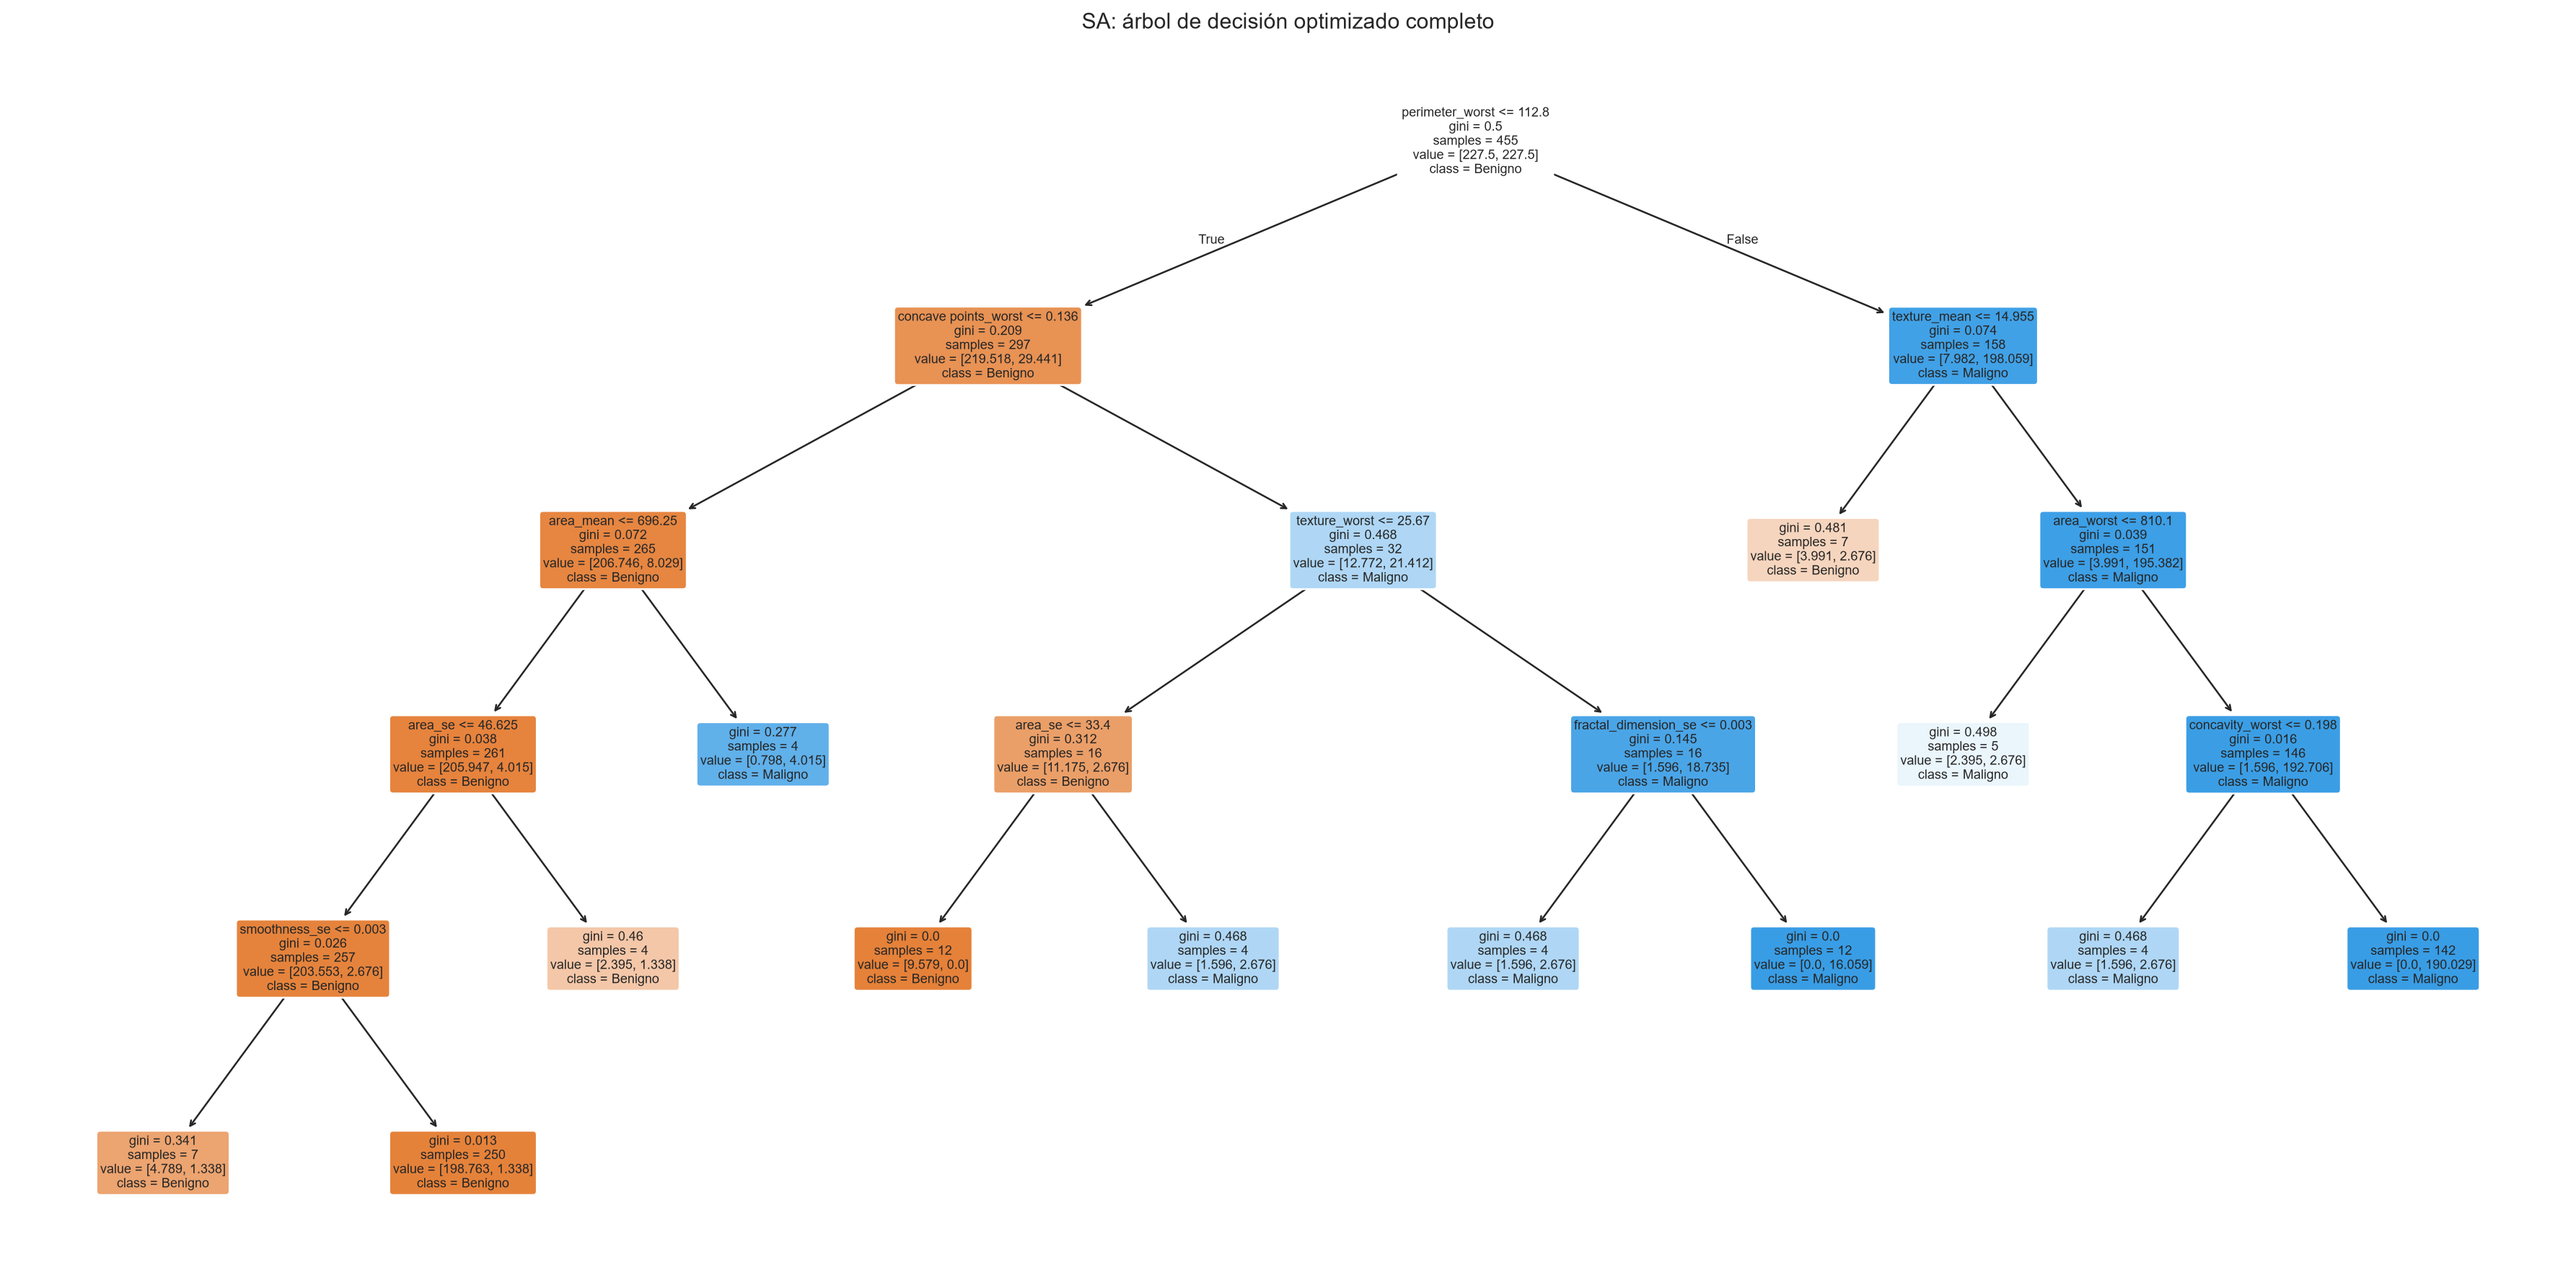

In [ ]:
figura, ejes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(confusion_matrix(y_prueba, prediccion), annot=True, fmt="d", ax=ejes[0])
ejes[0].set_title("Matriz de confusión")
ejes[0].set_xlabel("Predicción")
ejes[0].set_ylabel("Real")

RocCurveDisplay.from_predictions(y_prueba, probabilidad, ax=ejes[1])
ejes[1].plot([0, 1], [0, 1], "--", color="gray")
ejes[1].set_title("Curva ROC")

plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(busqueda.best_estimator_, ruta / "models" / "de_svm_breast_cancer.joblib")

## Interpretación

SVM logró un AUC alto y detectó casi todos los casos malignos. La matriz de confusión permite revisar el único error del conjunto de prueba.